Preparing Ground Truth Object...
Simulating capture of LR images with unknown 200.0 um defocus...

--- Starting Fast Auto-Focus Z-Sweep ---
Autofocus Complete! Optimal Z found at: 200.0 um

Running Full 30-iteration FPM using Z = 200.0 um...


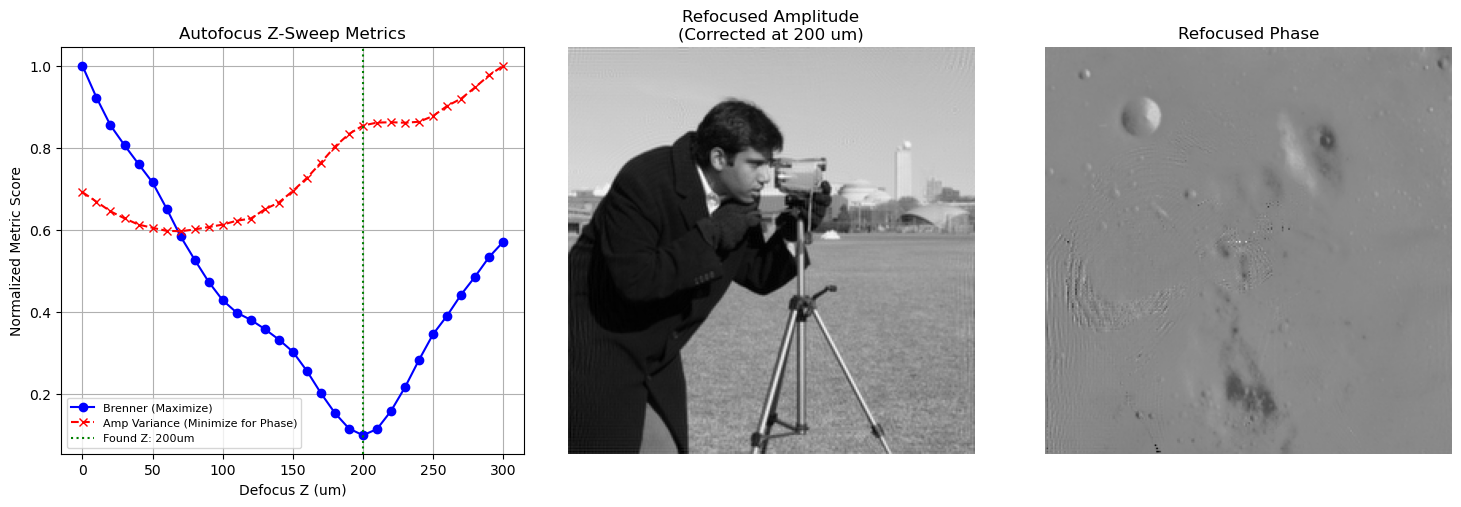

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def compute_focus_metrics(amp_image):
    """
    Computes focus metrics for a given amplitude image.
    1. Brenner Gradient (Maximizes at focus for amplitude features)
    2. Amplitude Variance/Modulation (Minimizes at focus for pure phase objects)
    """
    # Brenner gradient: square of differences between pixels separated by 2
    brenner = np.sum((amp_image[2:, :] - amp_image[:-2, :])**2)
    
    # Amplitude modulation: variance of the amplitude
    amp_modulation = np.var(amp_image)
    
    return brenner, amp_modulation

def simulate_autofocus_fpm():
    """
    Simulates defocused FPM data, runs a fast autofocus sweep to find z, 
    and then performs the final wavefront-corrected reconstruction.
    """
    # ==========================================
    # 1. System Parameters & Setup
    # ==========================================
    wavelength = 0.532e-3  # mm (532 nm)
    NA_obj = 0.1
    mag = 2.0
    
    led_grid_size = 7
    led_spacing = 4.0      # mm
    z_led = 60.0           # mm
    
    # The UNKNOWN physical defocus in the lab (150 um)
    actual_z_defocus = 0.200 
    
    cam_pixel_size = 6.5e-3 
    dx_lr = cam_pixel_size / mag 
    
    upsample_factor = 4
    N_lr = 64
    N_hr = N_lr * upsample_factor
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Ground Truth Object
    # ==========================================
    print("Preparing Ground Truth Object...")
    amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    obj_hr_gt = amp * np.exp(1j * phase)
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # ==========================================
    # 3. Spatial Frequencies & Forward Model
    # ==========================================
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    cutoff_freq = NA_obj / wavelength
    pupil_radius = np.sqrt(FX_lr**2 + FY_lr**2)
    pupil_ideal = (pupil_radius <= cutoff_freq).astype(float)
    
    # Calculate kz for defocus phase mapping
    radicand = np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    
    print(f"Simulating capture of LR images with unknown {actual_z_defocus*1000} um defocus...")
    pupil_physical = pupil_ideal * np.exp(1j * actual_z_defocus * kz)
    
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
            y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
            x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
            
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_sub = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                O_sub = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            E_lr_fourier = O_sub * pupil_physical
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            I_measured[i, j] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 4. Fast Auto-Focusing Sweep Algorithm
    # ==========================================
    print("\n--- Starting Fast Auto-Focus Z-Sweep ---")
    # We sweep from 0 to 300 um in 10 um steps
    z_search_range = np.linspace(0.0, 0.300, 31) 
    brenner_scores = []
    amp_var_scores = []
    
    # To save time, only use the central 3x3 LEDs for the autofocus search
    center = led_grid_size // 2
    search_indices = [center-1, center, center+1]
    
    for z_test in z_search_range:
        # Create test pupil with current z guess
        pupil_test = pupil_ideal * np.exp(1j * z_test * kz)
        pupil_intensity = np.abs(pupil_test)**2
        max_pupil = np.max(pupil_intensity)
        
        # Initialize small reconstruction
        O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
        initial_amp = np.sqrt(I_measured[center, center])
        O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
        
        # Run only 3 iterations on the 3x3 subset! (Blazing fast)
        for it in range(3):
            for i in search_indices:
                for j in search_indices:
                    shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                    shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                    
                    cy, cx = N_hr//2 + shift_y, N_hr//2 + shift_x
                    y_start, y_end = cy - N_lr//2, cy + N_lr//2
                    x_start, x_end = cx - N_lr//2, cx + N_lr//2
                    
                    O_sub = O_recon[y_start:y_end, x_start:x_end]
                    
                    E_est_fourier = O_sub * pupil_test
                    E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                    
                    amp_measured = np.sqrt(I_measured[i, j])
                    E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                    E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                    
                    update = (np.conj(pupil_test) / max_pupil) * (E_updated_fourier - E_est_fourier)
                    O_recon[y_start:y_end, x_start:x_end] += update
        
        # Evaluate metrics on the rapidly reconstructed amplitude
        obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
        amp_recon = np.abs(obj_recon_spatial)
        
        b_score, v_score = compute_focus_metrics(amp_recon)
        brenner_scores.append(b_score)
        amp_var_scores.append(v_score)

    # For our mixed object (Cameraman has strong amplitude edges), Brenner is the reliable metric.
    # If this was a purely transparent biological cell, we would minimize the amp_var_scores instead.
    best_z_idx = np.argmin(brenner_scores)
    optimal_z = z_search_range[best_z_idx]
    
    print(f"Autofocus Complete! Optimal Z found at: {optimal_z*1000:.1f} um")
    
    # ==========================================
    # 5. Full Final Reconstruction with Optimal Z
    # ==========================================
    print(f"\nRunning Full 30-iteration FPM using Z = {optimal_z*1000:.1f} um...")
    pupil_optimal = pupil_ideal * np.exp(1j * optimal_z * kz)
    pupil_intensity = np.abs(pupil_optimal)**2
    max_pupil = np.max(pupil_intensity)
    
    O_recon_final = np.zeros((N_hr, N_hr), dtype=np.complex128)
    initial_amp = np.sqrt(I_measured[center, center])
    O_recon_final[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                  N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
    
    # Full loop (49 LEDs, 30 Iterations)
    for it in range(30):
        for i in range(led_grid_size):
            for j in range(led_grid_size):
                shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                
                cy, cx = N_hr//2 + shift_y, N_hr//2 + shift_x
                y_start, y_end = cy - N_lr//2, cy + N_lr//2
                x_start, x_end = cx - N_lr//2, cx + N_lr//2
                
                if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                    continue
                
                O_sub = O_recon_final[y_start:y_end, x_start:x_end]
                
                E_est_fourier = O_sub * pupil_optimal
                E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                
                amp_measured = np.sqrt(I_measured[i, j])
                E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                
                update = (np.conj(pupil_optimal) / max_pupil) * (E_updated_fourier - E_est_fourier)
                O_recon_final[y_start:y_end, x_start:x_end] += update
                
    final_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon_final)))
    final_amp = np.abs(final_spatial)
    final_phase = np.angle(final_spatial)

    # ==========================================
    # 6. Visualization
    # ==========================================
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Autofocus Metrics
    plt.subplot(1, 3, 1)
    plt.title("Autofocus Z-Sweep Metrics")
    # Normalize for comparison
    norm_brenner = np.array(brenner_scores) / np.max(brenner_scores)
    norm_amp_var = np.array(amp_var_scores) / np.max(amp_var_scores)
    
    plt.plot(z_search_range * 1000, norm_brenner, 'b-o', label='Brenner (Maximize)')
    plt.plot(z_search_range * 1000, norm_amp_var, 'r--x', label='Amp Variance (Minimize for Phase)')
    plt.axvline(optimal_z * 1000, color='g', linestyle=':', label=f'Found Z: {optimal_z*1000:.0f}um')
    plt.xlabel("Defocus Z (um)")
    plt.ylabel("Normalized Metric Score")
    plt.legend(fontsize=8)
    plt.grid(True)
    
    # Plot 2: Final Amplitude
    plt.subplot(1, 3, 2)
    plt.title(f"Refocused Amplitude\n(Corrected at {optimal_z*1000:.0f} um)")
    plt.imshow(final_amp, cmap='gray')
    plt.axis('off')
    
    # Plot 3: Final Phase
    plt.subplot(1, 3, 3)
    plt.title("Refocused Phase")
    plt.imshow(final_phase, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_autofocus_fpm()

Initializing optical parameters and ground truth...
Simulating hardware capture... (Sample is physically misaligned by 120.0 um)
Executing Autofocus Z-Sweep...
  Guessed Z: -400.0 um | Brenner Score: 4.01e+03
  Guessed Z: -360.0 um | Brenner Score: 3.49e+03
  Guessed Z: -320.0 um | Brenner Score: 3.60e+03
  Guessed Z: -280.0 um | Brenner Score: 3.13e+03
  Guessed Z: -240.0 um | Brenner Score: 2.75e+03
  Guessed Z: -200.0 um | Brenner Score: 2.42e+03
  Guessed Z: -160.0 um | Brenner Score: 2.12e+03
  Guessed Z: -120.0 um | Brenner Score: 1.89e+03
  Guessed Z:  -80.0 um | Brenner Score: 1.55e+03
  Guessed Z:  -40.0 um | Brenner Score: 1.32e+03
  Guessed Z:    0.0 um | Brenner Score: 1.13e+03
  Guessed Z:   40.0 um | Brenner Score: 9.74e+02
  Guessed Z:   80.0 um | Brenner Score: 8.83e+02
  Guessed Z:  120.0 um | Brenner Score: 9.77e+02
  Guessed Z:  160.0 um | Brenner Score: 9.53e+02
  Guessed Z:  200.0 um | Brenner Score: 1.18e+03
  Guessed Z:  240.0 um | Brenner Score: 1.37e+03
  Guess

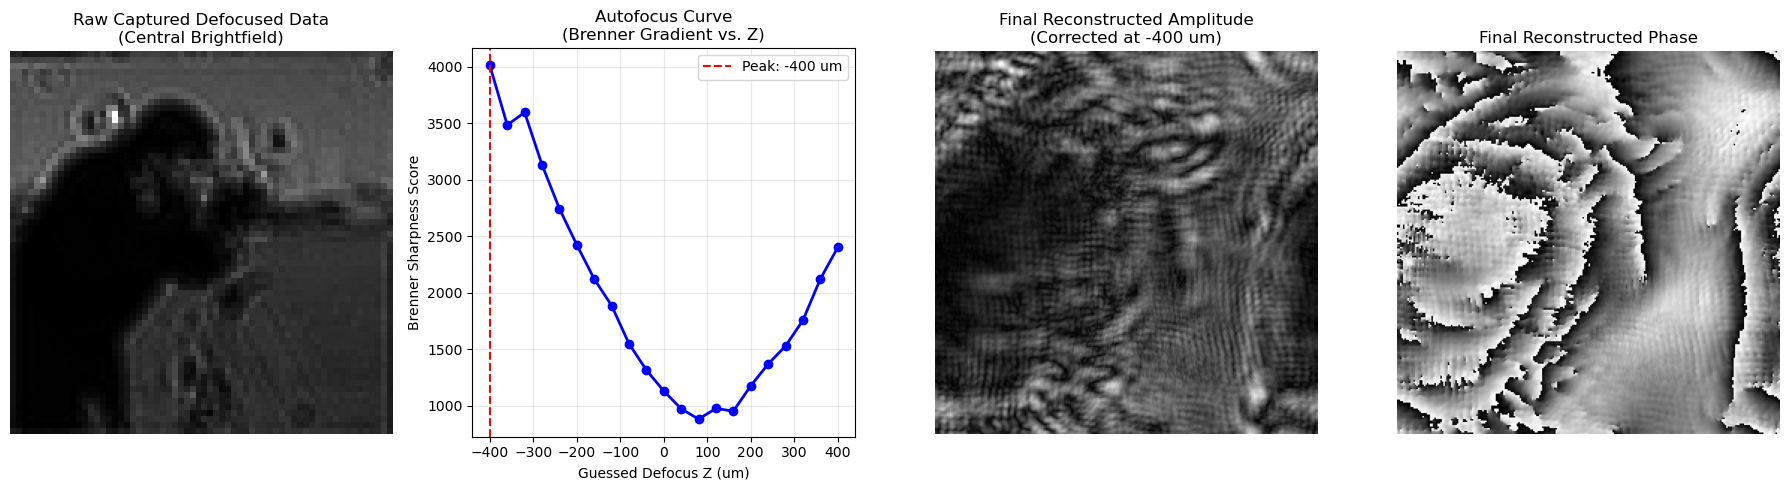

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def simulate_autofocus_fpm():
    """
    Simulates FPM with an unknown defocused sample and implements 
    an algorithmic auto-focusing sweep using the Brenner gradient.
    """
    # ==========================================
    # 1. System & Setup Parameters
    # ==========================================
    wavelength = 0.532e-3  # 532 nm Green LED in mm
    NA_obj = 0.1           
    mag = 2.0              
    
    led_grid_size = 7      # 7x7 array
    led_spacing = 4.0      # 4mm spacing
    z_led = 60.0           # LED to sample distance in mm
    
    # The HIDDEN true defocus (The algorithm does not know this!)
    true_z_defocus = 0.120 # 120 um defocus
    
    cam_pixel_size = 6.5e-3 
    dx_lr = cam_pixel_size / mag 
    
    upsample_factor = 4
    N_lr = 64              
    N_hr = N_lr * upsample_factor 
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Ground Truth & Frequency Grids
    # ==========================================
    print("Initializing optical parameters and ground truth...")
    amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    
    obj_hr_gt = amp * np.exp(1j * phase)
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # Spatial frequency grids
    fx_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    fy_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    # Ideal Low-Pass Pupil
    cutoff_freq = NA_obj / wavelength
    pupil_ideal = (np.sqrt(FX_lr**2 + FY_lr**2) <= cutoff_freq).astype(float)
    
    # Kz for wave propagation
    radicand = np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    
    # True aberrated pupil (used ONLY for generating measured data)
    pupil_true = pupil_ideal * np.exp(1j * true_z_defocus * kz)
    
    # ==========================================
    # 3. Forward Model: Capture Data
    # ==========================================
    print(f"Simulating hardware capture... (Sample is physically misaligned by {true_z_defocus*1000} um)")
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
            y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
            x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
            
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_sub = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                O_sub = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            # Field propagates through the physically defocused pupil
            E_lr_fourier = O_sub * pupil_true
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            I_measured[i, j] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 4. Inverse Model & Autofocus Functions
    # ==========================================
    def calculate_brenner_gradient(image):
        """Calculates the Brenner gradient for image sharpness assessment."""
        # Measures the squared difference between pixels separated by a distance of 2
        dx = image[:, 2:] - image[:, :-2]
        dy = image[2:, :] - image[:-2, :]
        return np.sum(dx**2) + np.sum(dy**2)

    def reconstruct_fpm(z_guess, iterations=5):
        """Runs FPM reconstruction given a specific z_guess."""
        # Generate the digital pupil for this specific z_guess
        pupil_guess = pupil_ideal * np.exp(1j * z_guess * kz)
        pupil_intensity = np.abs(pupil_guess)**2
        max_pupil = np.max(pupil_intensity)
        
        O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
        center_idx = led_grid_size // 2
        
        initial_amp = np.sqrt(I_measured[center_idx, center_idx])
        E_init_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
        O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = E_init_fourier
        
        for it in range(iterations):
            for i in range(led_grid_size):
                for j in range(led_grid_size):
                    shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                    shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                    
                    center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
                    y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
                    x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
                    
                    if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                        continue
                    
                    O_sub = O_recon[y_start:y_end, x_start:x_end]
                    
                    # Forward digital projection
                    E_est_fourier = O_sub * pupil_guess
                    E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                    
                    # Intensity constraint
                    amp_measured = np.sqrt(I_measured[i, j])
                    E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                    E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                    
                    # Inverse digital update
                    update = (np.conj(pupil_guess) / max_pupil) * (E_updated_fourier - E_est_fourier)
                    O_recon[y_start:y_end, x_start:x_end] += update

        obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
        return np.abs(obj_recon_spatial), np.angle(obj_recon_spatial)

    # ==========================================
    # 5. Execute Autofocus Sweep
    # ==========================================
    print("Executing Autofocus Z-Sweep...")
    # Sweep from -200 um to +200 um in steps of 20 um
    z_sweep_range = np.linspace(-0.400, 0.400, 21) 
    brenner_scores = []
    
    for z in z_sweep_range:
        # Run a truncated 3-iteration reconstruction for speed
        amp_recon, _ = reconstruct_fpm(z, iterations=3)
        score = calculate_brenner_gradient(amp_recon)
        brenner_scores.append(score)
        print(f"  Guessed Z: {z*1000: >6.1f} um | Brenner Score: {score:.2e}")

    # Identify the optimal z
    optimal_idx = np.argmax(brenner_scores)
    optimal_z = z_sweep_range[optimal_idx]
    print(f"\n=> Autofocus Complete! Optimal Z identified at: {optimal_z*1000:.1f} um")
    
    # ==========================================
    # 6. Final High-Fidelity Reconstruction
    # ==========================================
    print("Running final high-iteration reconstruction with optimal Z...")
    final_amp, final_phase = reconstruct_fpm(optimal_z, iterations=30)

    # ==========================================
    # 7. Visualization
    # ==========================================
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 4, 1)
    plt.title(f"Raw Captured Defocused Data\n(Central Brightfield)")
    plt.imshow(I_measured[led_grid_size//2, led_grid_size//2], cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title("Autofocus Curve\n(Brenner Gradient vs. Z)")
    plt.plot(z_sweep_range * 1000, brenner_scores, 'bo-', linewidth=2)
    plt.axvline(optimal_z * 1000, color='r', linestyle='--', label=f'Peak: {optimal_z*1000:.0f} um')
    plt.xlabel("Guessed Defocus Z (um)")
    plt.ylabel("Brenner Sharpness Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 4, 3)
    plt.title(f"Final Reconstructed Amplitude\n(Corrected at {optimal_z*1000:.0f} um)")
    plt.imshow(final_amp, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title("Final Reconstructed Phase")
    plt.imshow(final_phase, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_autofocus_fpm()

Simulating physical setup with an unknown defocus of 120.0 um...

--- Starting Autofocus Search ---
Test z =  50.0 um | Brenner Score: 9.7977e+02
Test z =  60.0 um | Brenner Score: 9.5304e+02
Test z =  70.0 um | Brenner Score: 9.1719e+02
Test z =  80.0 um | Brenner Score: 9.1341e+02
Test z =  90.0 um | Brenner Score: 8.8710e+02
Test z = 100.0 um | Brenner Score: 9.2944e+02
Test z = 110.0 um | Brenner Score: 9.8023e+02
Test z = 120.0 um | Brenner Score: 1.0085e+03
Test z = 130.0 um | Brenner Score: 9.7775e+02
Test z = 140.0 um | Brenner Score: 9.4491e+02
Test z = 150.0 um | Brenner Score: 9.3788e+02

>> Autofocus Complete! Optimal defocus found at: 90.0 um
Running final deep reconstruction (30 iterations) at optimal z...


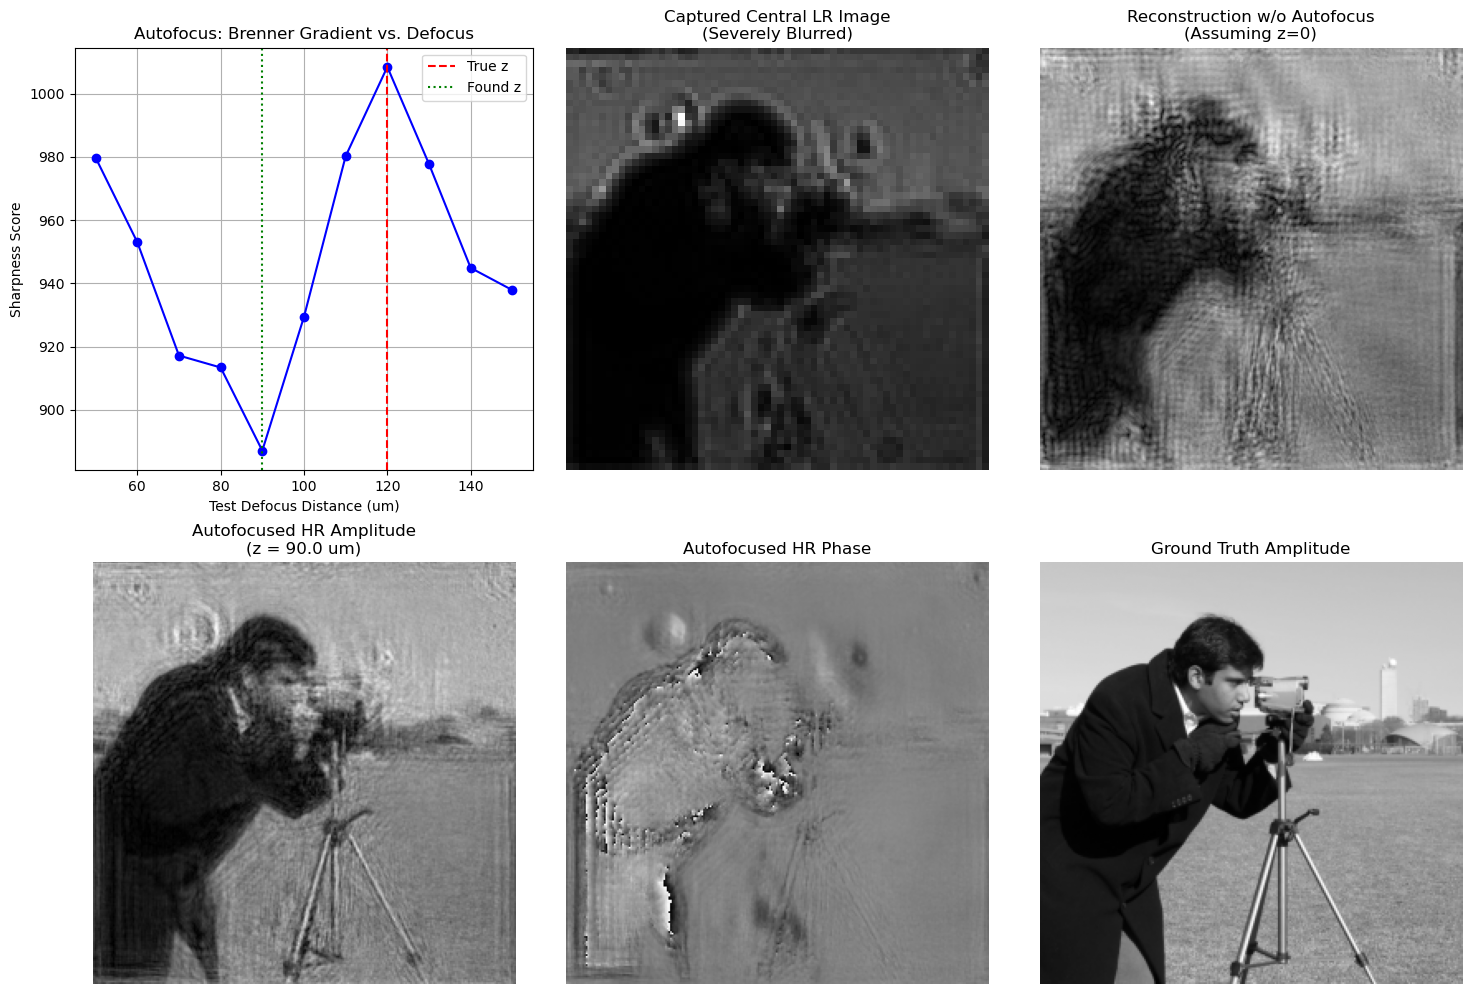

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def calculate_brenner_gradient(image):
    """
    Calculates the Brenner gradient of an image to measure its sharpness.
    It computes the finite difference between a pixel and its neighbor 
    two pixels away. A higher value indicates a sharper image.
    """
    # Use the amplitude/intensity for the sharpness metric
    img_array = np.abs(image)
    
    # Compute horizontal and vertical Brenner gradients
    dh = img_array[2:, :] - img_array[:-2, :]
    dv = img_array[:, 2:] - img_array[:, :-2]
    
    # Sum of squared differences
    brenner_val = np.sum(dh**2) + np.sum(dv**2)
    return brenner_val

def simulate_autofocus_fpm():
    """
    Simulates FPM with an unknown defocus and uses a Brenner gradient 
    search to automatically find the focal plane and reconstruct the HR object.
    """
    # ==========================================
    # 1. System Parameters & Setup
    # ==========================================
    wavelength = 0.532e-3  # Wavelength in mm (532 nm Green LED)
    NA_obj = 0.1           # Objective Numerical Aperture
    mag = 2.0              # Magnification
    
    # LED Array Parameters
    led_grid_size = 7      
    led_spacing = 4.0      
    z_led = 60.0           
    
    # The "Unknown" Ground Truth Defocus (e.g., 120 um)
    z_true_defocus = 0.120      
    
    # Resolution Parameters
    cam_pixel_size = 6.5e-3 
    dx_lr = cam_pixel_size / mag 
    
    upsample_factor = 4
    N_lr = 64              
    N_hr = N_lr * upsample_factor 
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Create the Ground Truth Object
    # ==========================================
    print(f"Simulating physical setup with an unknown defocus of {z_true_defocus*1000} um...")
    amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    obj_hr_gt = amp * np.exp(1j * phase)
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # ==========================================
    # 3. Frequency Coordinates & Defocused Forward Model
    # ==========================================
    fx_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    fy_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    # Ideal Pupil
    cutoff_freq = NA_obj / wavelength
    pupil_radius = np.sqrt(FX_lr**2 + FY_lr**2)
    pupil_ideal = (pupil_radius <= cutoff_freq).astype(float)
    
    # True Aberrated Pupil (Simulating the physical world)
    radicand = np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    true_defocus_phase = z_true_defocus * kz
    pupil_physical = pupil_ideal * np.exp(1j * true_defocus_phase)
    
    # Generate LR Images
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
            y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
            x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
            
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_sub = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                O_sub = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            E_lr_fourier = O_sub * pupil_physical
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            I_measured[i, j] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 4. Core FPM Reconstruction Function
    # ==========================================
    def reconstruct_fpm(z_test, iterations):
        """Runs FPM for a given test defocus distance z_test."""
        # Generate the digital pupil for this specific z_test
        test_phase = z_test * kz
        pupil_test = pupil_ideal * np.exp(1j * test_phase)
        
        O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
        center_idx = led_grid_size // 2
        
        initial_amp = np.sqrt(I_measured[center_idx, center_idx])
        E_init_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
        O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = E_init_fourier
        
        pupil_intensity = np.abs(pupil_test)**2
        max_pupil = np.max(pupil_intensity)
        
        for it in range(iterations):
            for i in range(led_grid_size):
                for j in range(led_grid_size):
                    shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                    shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                    
                    center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
                    y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
                    x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
                    
                    if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                        continue
                    
                    O_sub = O_recon[y_start:y_end, x_start:x_end]
                    
                    E_est_fourier = O_sub * pupil_test
                    E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                    
                    amp_measured = np.sqrt(I_measured[i, j])
                    E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                    E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                    
                    # Applying complex conjugate of pupil_test applies the inverse wavefront correction
                    update = (np.conj(pupil_test) / max_pupil) * (E_updated_fourier - E_est_fourier)
                    O_recon[y_start:y_end, x_start:x_end] += update

        obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
        return obj_recon_spatial

    # ==========================================
    # 5. The Autofocus Search Algorithm
    # ==========================================
    print("\n--- Starting Autofocus Search ---")
    # Sweep z from 0 to 250 um in steps of 25 um
    z_search_space = np.linspace(0.050, 0.150, 11) 
    brenner_scores = []
    
    # We use fewer iterations (e.g., 8) for the search to save time. 
    # This is usually enough for the lower spatial frequencies to converge 
    # and give a reliable gradient metric.
    fast_iterations = 8 
    
    for z_test in z_search_space:
        hr_complex_field = reconstruct_fpm(z_test, iterations=fast_iterations)
        score = calculate_brenner_gradient(np.abs(hr_complex_field))
        brenner_scores.append(score)
        print(f"Test z = {z_test*1000:5.1f} um | Brenner Score: {score:.4e}")
        
    # Find the z that yielded the maximum Brenner gradient
    optimal_idx = np.argmin(brenner_scores)
    z_optimal = z_search_space[optimal_idx]
    
    print(f"\n>> Autofocus Complete! Optimal defocus found at: {z_optimal*1000:.1f} um")
    
    # ==========================================
    # 6. Final High-Fidelity Reconstruction
    # ==========================================
    print(f"Running final deep reconstruction (30 iterations) at optimal z...")
    final_hr_field = reconstruct_fpm(z_optimal, iterations=30)
    amp_recon = np.abs(final_hr_field)
    phase_recon = np.angle(final_hr_field)
    
    # ==========================================
    # 7. Visualization
    # ==========================================
    plt.figure(figsize=(15, 10))
    
    # Plot 1: The Sharpness Curve
    plt.subplot(2, 3, 1)
    plt.title("Autofocus: Brenner Gradient vs. Defocus")
    plt.plot(z_search_space * 1000, brenner_scores, 'bo-')
    plt.axvline(x=z_true_defocus * 1000, color='r', linestyle='--', label='True z')
    plt.axvline(x=z_optimal * 1000, color='g', linestyle=':', label='Found z')
    plt.xlabel("Test Defocus Distance (um)")
    plt.ylabel("Sharpness Score")
    plt.legend()
    plt.grid(True)
    
    # Plot 2: Center LR Image (Blurred)
    center_idx = led_grid_size // 2
    plt.subplot(2, 3, 2)
    plt.title("Captured Central LR Image\n(Severely Blurred)")
    plt.imshow(I_measured[center_idx, center_idx], cmap='gray')
    plt.axis('off')
    
    # Plot 3: Uncorrected HR (If we assumed z=0)
    # We run a quick uncorrected reconstruction just for visual comparison
    bad_hr_field = reconstruct_fpm(0.0, iterations=15)
    plt.subplot(2, 3, 3)
    plt.title("Reconstruction w/o Autofocus\n(Assuming z=0)")
    plt.imshow(np.abs(bad_hr_field), cmap='gray')
    plt.axis('off')
    
    # Plot 4: Final Corrected HR Amplitude
    plt.subplot(2, 3, 4)
    plt.title(f"Autofocused HR Amplitude\n(z = {z_optimal*1000:.1f} um)")
    plt.imshow(amp_recon, cmap='gray')
    plt.axis('off')
    
    # Plot 5: Final Corrected HR Phase
    plt.subplot(2, 3, 5)
    plt.title("Autofocused HR Phase")
    plt.imshow(phase_recon, cmap='gray')
    plt.axis('off')
    
    # Plot 6: Ground Truth Amplitude for Reference
    plt.subplot(2, 3, 6)
    plt.title("Ground Truth Amplitude")
    plt.imshow(amp, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_autofocus_fpm()

1/4: Preparing Ground Truth Object...
2/4: Simulating captured LR images with 150.0 um defocus...
3/4: Starting EPRY Joint Reconstruction (Blind to Defocus)...
     Iteration 10/30 completed.
     Iteration 20/30 completed.
     Iteration 30/30 completed.
4/4: Plotting Results...


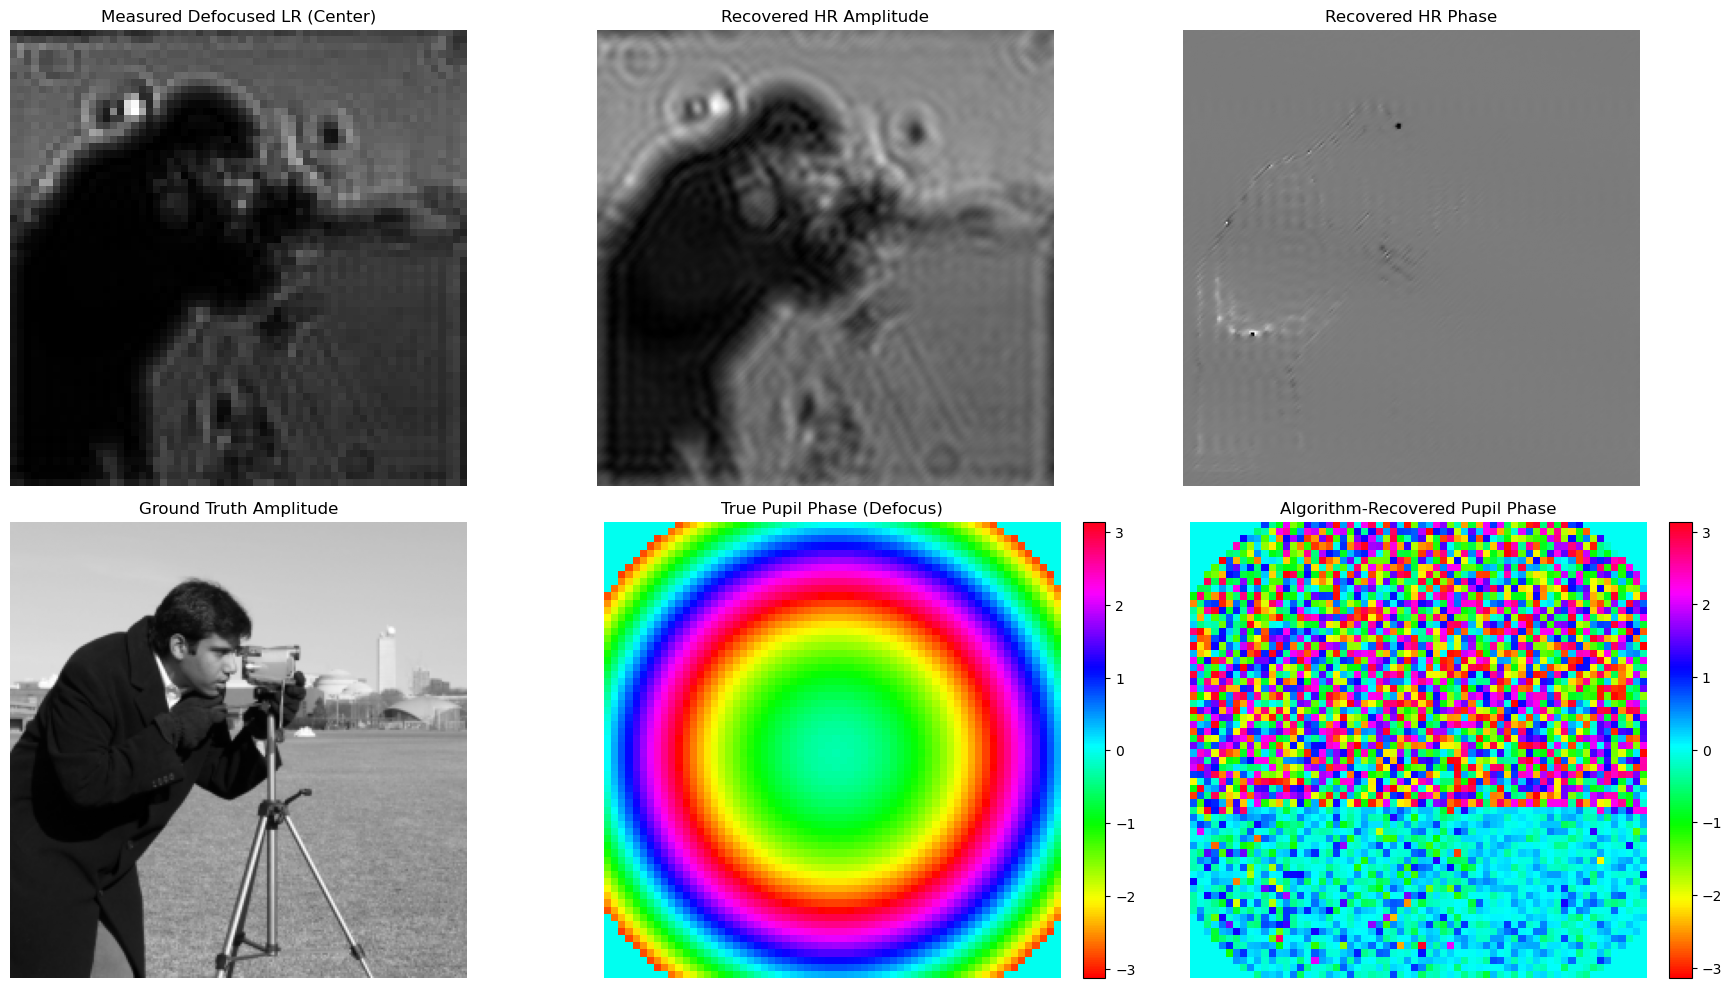

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def simulate_epry_fpm():
    """
    Simulates FPM with an unknown defocus and uses the Embedded Pupil Function 
    Recovery (EPRY) algorithm to jointly recover the HR object and the pupil phase.
    """
    # ==========================================
    # 1. System Parameters & Setup
    # ==========================================
    wavelength = 0.532e-3  # Wavelength in mm (532 nm Green LED)
    NA_obj = 0.1           # Objective Numerical Aperture
    mag = 2.0              # Magnification
    
    # LED Array Parameters
    led_grid_size = 7      # 7x7 LED array
    led_spacing = 4.0      # 4mm spacing between LEDs
    z_led = 60.0           # Distance from LED array to sample in mm
    
    # Unknown Physical Defocus (Hidden from the inverse model)
    true_z_defocus = 0.150 # 150 um defocus
    
    # Camera / Resolution Parameters
    cam_pixel_size = 6.5e-3 
    dx_lr = cam_pixel_size / mag  # Effective pixel size at the object plane
    
    upsample_factor = 4
    N_lr = 64              # LR image size
    N_hr = N_lr * upsample_factor # HR image size (256x256)
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Ground Truth Generation
    # ==========================================
    print("1/4: Preparing Ground Truth Object...")
    amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    obj_hr_gt = amp * np.exp(1j * phase)
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # ==========================================
    # 3. Define Pupils and Forward Model (Physical Capture)
    # ==========================================
    fx_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    fy_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    # Ideal Pupil Support (Physical Aperture)
    cutoff_freq = NA_obj / wavelength
    pupil_radius = np.sqrt(FX_lr**2 + FY_lr**2)
    pupil_support = (pupil_radius <= cutoff_freq).astype(float)
    
    # True Aberrated Pupil (used ONLY for generating measured data)
    radicand = np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    true_defocus_phase = true_z_defocus * kz
    pupil_true = pupil_support * np.exp(1j * true_defocus_phase)
    
    print(f"2/4: Simulating captured LR images with {true_z_defocus*1000} um defocus...")
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
            y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
            x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
            
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_sub = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                O_sub = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            E_lr_fourier = O_sub * pupil_true
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            I_measured[i, j] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 4. Inverse Model: Auto-Defocusing (EPRY)
    # ==========================================
    print("3/4: Starting EPRY Joint Reconstruction (Blind to Defocus)...")
    
    # Initialize Object Spectrum (O_recon)
    O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
    center_idx = led_grid_size // 2
    initial_amp = np.sqrt(I_measured[center_idx, center_idx])
    E_init_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
    O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
            N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = E_init_fourier
            
    # Initialize Pupil (P_recon) with a flat phase guess
    P_recon = np.copy(pupil_support).astype(np.complex128)
    
    iterations = 30
    alpha_obj = 1.0   # Object update step size
    alpha_pupil = 1.0 # Pupil update step size
    
    for it in range(iterations):
        if (it+1) % 10 == 0:
            print(f"     Iteration {it+1}/{iterations} completed.")
            
        for i in range(led_grid_size):
            for j in range(led_grid_size):
                shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                
                center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
                y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
                x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
                
                if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                    continue
                
                # 1. Extract current Object sub-spectrum
                O_sub = O_recon[y_start:y_end, x_start:x_end]
                
                # 2. Forward estimate using current Pupil guess
                E_est_fourier = O_sub * P_recon
                E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                
                # 3. Apply measured amplitude constraint
                amp_measured = np.sqrt(I_measured[i, j])
                E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                
                # 4. Calculate spectral difference
                dE = E_updated_fourier - E_est_fourier
                
                # 5. Joint Optimization Updates
                # Update Object Spectrum (using current Pupil)
                max_P = np.max(np.abs(P_recon)**2)
                O_recon[y_start:y_end, x_start:x_end] += alpha_obj * (np.conj(P_recon) / max_P) * dE
                
                # Update Pupil Function (using current Object sub-spectrum)
                max_O = np.max(np.abs(O_sub)**2)
                # To avoid division by zero in dark regions, add a small epsilon if needed, 
                # but dividing by global max_O is generally stable.
                P_recon += alpha_pupil * (np.conj(O_sub) / max_O) * dE
                
                # 6. Enforce physical aperture constraint on the updated pupil
                # The pupil cannot exist outside the NA limit of the objective
                P_recon *= pupil_support

    # Final spatial domain transforms
    obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
    amp_recon = np.abs(obj_recon_spatial)
    phase_recon = np.angle(obj_recon_spatial)
    pupil_phase_recon = np.angle(P_recon) * pupil_support # Masked for visualization

    # ==========================================
    # 5. Visualization
    # ==========================================
    print("4/4: Plotting Results...")
    plt.figure(figsize=(18, 10))
    
    plt.subplot(2, 3, 1)
    plt.title("Measured Defocused LR (Center)")
    plt.imshow(I_measured[center_idx, center_idx], cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 2)
    plt.title("Recovered HR Amplitude")
    plt.imshow(amp_recon, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 3)
    plt.title("Recovered HR Phase")
    plt.imshow(phase_recon, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 4)
    plt.title("Ground Truth Amplitude")
    plt.imshow(amp, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.title("True Pupil Phase (Defocus)")
    # Normalize phase for display
    plt.imshow(np.angle(pupil_true) * pupil_support, cmap='hsv')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.subplot(2, 3, 6)
    plt.title("Algorithm-Recovered Pupil Phase")
    plt.imshow(pupil_phase_recon, cmap='hsv')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_epry_fpm()
    